In [15]:
import pandas as pd
import numpy as np

In [16]:
df = pd.read_csv('US_Accidents_March23_Fix.csv')

In [17]:
df.shape

(7728394, 46)

In [18]:
df.Severity.value_counts()

Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

In [19]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


C:\Users\frans\AppData\Local\Temp\ipykernel_12952\936707398.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Severity', data=df, palette='viridis')


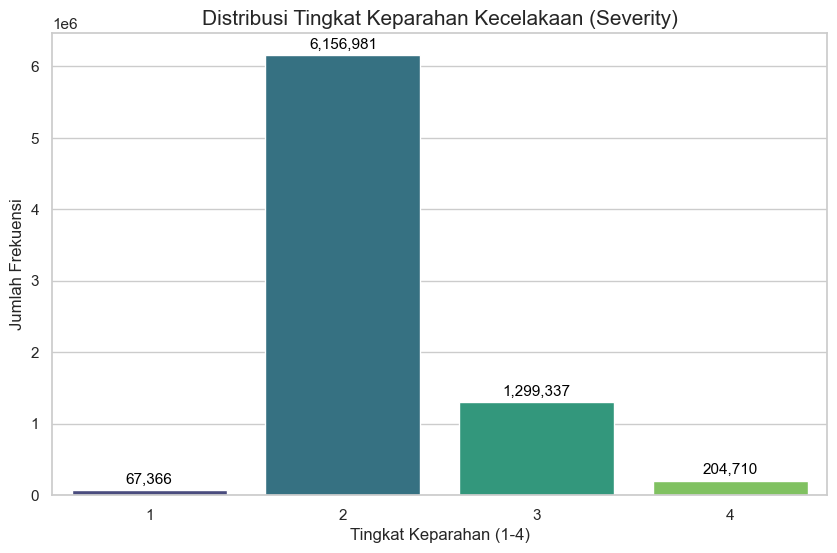

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan estetika seaborn
sns.set_theme(style="whitegrid")

# 1. Menghitung distribusi Severity untuk referensi tabel
severity_counts = df['Severity'].value_counts().sort_index().reset_index()
severity_counts.columns = ['Severity', 'Jumlah Kecelakaan']

# 2. Membuat Visualisasi
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Severity', data=df, palette='viridis')

# Menambahkan label jumlah di atas setiap bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribusi Tingkat Keparahan Kecelakaan (Severity)', fontsize=15)
plt.xlabel('Tingkat Keparahan (1-4)', fontsize=12)
plt.ylabel('Jumlah Frekuensi', fontsize=12)
plt.show()

In [22]:
df.shape

(7728394, 46)

In [24]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')

In [25]:
df['Tahun'] = df['Start_Time'].dt.year

In [26]:
df.Tahun.value_counts()

Tahun
2022    1762452
2021    1563753
2020    1178913
2019     954303
2018     893426
2017     718093
2016     410821
2023     246633
Name: count, dtype: int64

In [27]:
persebaran_severity = pd.crosstab(df['Tahun'], df['Severity'])

print("Persebaran Severity Per Tahun:")
print(persebaran_severity)

persentase_severity = pd.crosstab(df['Tahun'], df['Severity'], normalize='index')

Persebaran Severity Per Tahun:
Severity      1        2       3      4
Tahun                                  
2016        225   270026  126215  14355
2017        282   462474  231169  24168
2018        259   574668  292706  25793
2019        203   688144  237853  28103
2020      28371   934123  185352  31067
2021        151  1384628  148085  30889
2022      37875  1603346   77957  43274
2023          0   239572       0   7061


Pilih data di tahun 2020 karena distribusi datanya lebih kaya. Lihat kolom Severity 1 dan 4. Dia lebih banyak di tahun 2022 dibandingkan yang lainnya.

Kita akan melakukan stratified sampling di severity 2 dan 3. Teknik ini memastikan bahwa meskipun kita mengambil sedikit data, komposisi fitur penting lainnya (misalnya: waktu, cuaca, atau lokasi) tetap terjaga proporsinya.

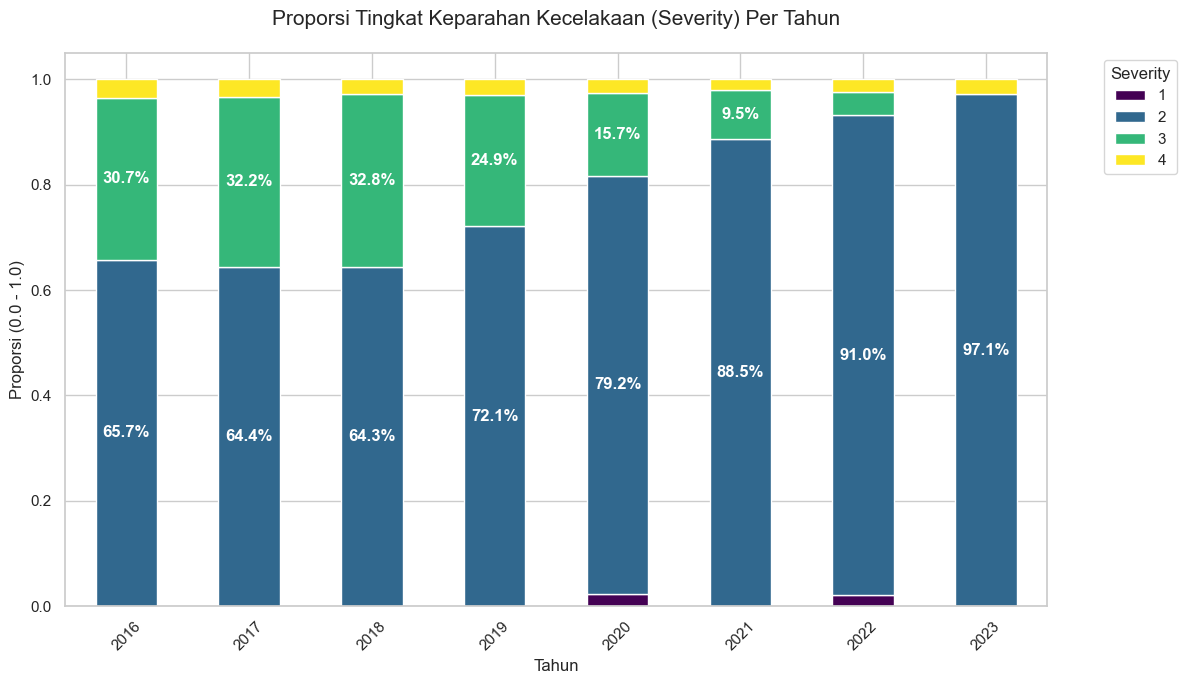

In [28]:
import matplotlib.pyplot as plt

# 1. Plotting Stacked Bar Chart dari DataFrame persentase_severity
ax = persentase_severity.plot(kind='bar', 
                              stacked=True, 
                              figsize=(12, 7), 
                              colormap='viridis', 
                              edgecolor='white')

# 2. Kostumisasi Grafik
plt.title('Proporsi Tingkat Keparahan Kecelakaan (Severity) Per Tahun', fontsize=15, pad=20)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Proporsi (0.0 - 1.0)', fontsize=12)
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# 3. Menambahkan Label Persentase di dalam Bar (Opsional tapi informatif)
for n, x in enumerate([*persentase_severity.index.values]):
    cumulative_height = 0
    for proportion in persentase_severity.loc[x]:
        if proportion > 0.05: # Hanya tampilkan label jika proporsi > 5% agar tidak berantakan
            plt.text(n, cumulative_height + proportion/2, f'{proportion*100:.1f}%', 
                     va='center', ha='center', color='white', fontweight='bold')
        cumulative_height += proportion

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd

# 1. Filter data hanya untuk tahun 2022
# Pastikan kamu sudah membuat kolom 'Tahun_Mulai' sebelumnya
df_2020 = df[df['Tahun'] == 2020].copy()

# 2. Simpan ke file CSV baru
# index=False sangat penting agar Pandas tidak membuat kolom tambahan untuk nomor baris
df_2020.to_csv('dataset_2020_clean.csv', index=False)

print(f"Berhasil! Data tahun 2020 telah disimpan dengan jumlah {len(df_2020)} baris.")

Berhasil! Data tahun 2020 telah disimpan dengan jumlah 1178913 baris.


--- Analisis Rasio (Semakin Kecil Semakin Bagus/Rata) ---
      Ratio_2_vs_1
Year              
2020     32.925276
2022     42.332568


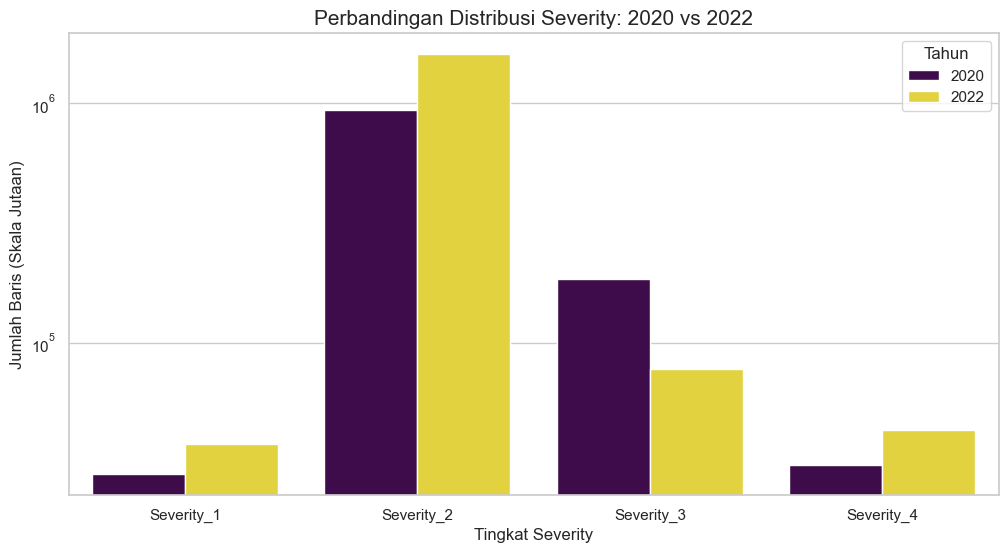

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Input data sesuai tabel yang kamu berikan
data = {
    'Year': [2020, 2022],
    'Severity_1': [28371, 37875],
    'Severity_2': [934123, 1603346],
    'Severity_3': [185352, 77957],
    'Severity_4': [31067, 43274]
}

df_ratio = pd.DataFrame(data).set_index('Year')

# 2. Hitung Rasio Severity 2 terhadap Severity 1
df_ratio['Ratio_2_vs_1'] = df_ratio['Severity_2'] / df_ratio['Severity_1']

print("--- Analisis Rasio (Semakin Kecil Semakin Bagus/Rata) ---")
print(df_ratio[['Ratio_2_vs_1']])

# 3. Visualisasi Perbandingan Distribusi
# Kita melt data supaya enak di-plot pakai Seaborn
df_plot = df_ratio.reset_index().melt(id_vars='Year', value_vars=['Severity_1', 'Severity_2', 'Severity_3', 'Severity_4'])

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plot Bar
ax = sns.barplot(data=df_plot, x='variable', y='value', hue='Year', palette='viridis')

plt.title('Perbandingan Distribusi Severity: 2020 vs 2022', fontsize=15)
plt.xlabel('Tingkat Severity', fontsize=12)
plt.ylabel('Jumlah Baris (Skala Jutaan)', fontsize=12)
plt.yscale('log') # Menggunakan skala logaritmik karena perbedaan angka yang ekstrem
plt.legend(title='Tahun')

# Tambahkan label rasio di atas bar
plt.show()